# Fake News Detection Using SVM(SVC + TF-IDF)


## 1. Introduction
Binary text classification project to detect fake vs real news articles using 

TF-IDF vectorization and a Linear Support Vector Classifier (SVM).

Dataset:  `mucahiddemircan/real-and-fake-news-dataset` , 45,757 articles, balanced classes.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading & Inspection

In [2]:
# load the datset

df = pd.read_csv("./data/news.csv")
df.head()

,text,label
0,Gere faults Trump for blurring meaning of 'ref...,1
1,German parties start to find common ground in ...,1
2,Senate Democratic leader says Attorney General...,1
3,"Tennis: Kyrgios fined $10,000 for Shanghai wal...",1
4,Trump Threw Mar-A-Lago Fundraiser For Woman A...,0


In [3]:
len(df)

45757

In [4]:
# check null values
df.isnull().sum()

text     0
label    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
# look for year 
old_years = df['text'].str.contains('2014|2015|2016', regex=True).sum()
recent_years = df['text'].str.contains('2024|2025|2026', regex=True).sum()
print(f"2014-2016 mentions: {old_years}")
print(f"2024-2026 mentions: {recent_years}")

2014-2016 mentions: 13977
2024-2026 mentions: 301


## 3. Exploratory Data Analysis(Word Clouds)

In [7]:
# install library to visually represent
%pip install wordcloud --q

Note: you may need to restart the kernel to use updated packages.


In [8]:
from wordcloud import WordCloud

# collect seperately Real and Fake new data

real_news = " ".join(df[df['label'] == 1]['text'])
fake_news = " ".join(df[df['label']==0]['text'])

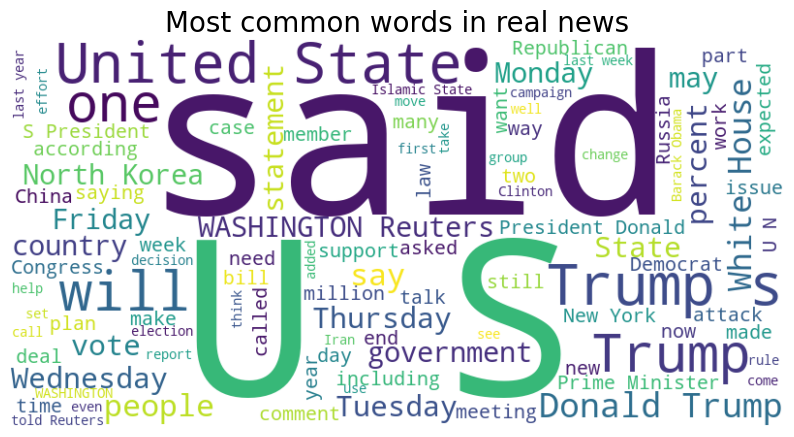

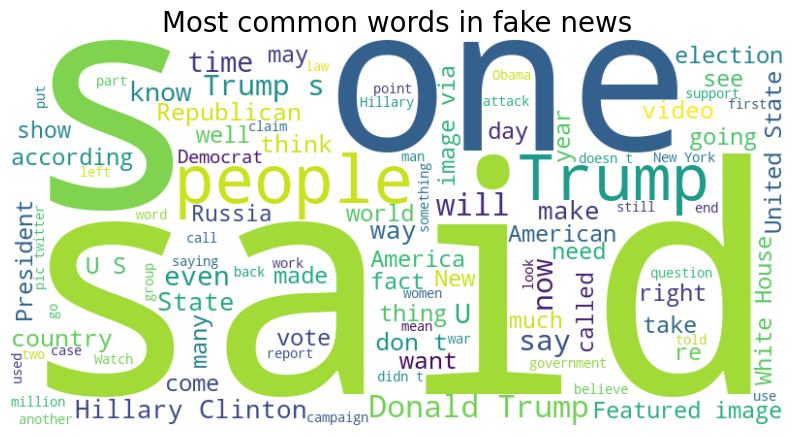

In [9]:
# create Function for WordCloud

def plot_wordcloud(text, title):
    wordcloud = WordCloud(width=800 , height = 400 , background_color='white' , 
                          max_words=100).generate(text)
    plt.figure(figsize=(10,15))
    plt.imshow(wordcloud , interpolation='bilinear')
    plt.axis('off')
    plt.title(title , fontsize=20)
    plt.show()

plot_wordcloud(real_news , "Most common words in real news")
plot_wordcloud(fake_news , "Most common words in fake news")

## 4. Preprocessing & Model Training(first pass)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report , accuracy_score

# select feature and target variables

X = df['text']

y = df['label']

# train test split
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.20 , 
                                                       random_state=42  , stratify=y)

# pipeline build

model_pipeline = make_pipeline(
    TfidfVectorizer(lowercase=True , stop_words='english' , max_features=1000)  ,
    LinearSVC(C = 1.0 , random_state = 42)
)


print("Pipeline is Ready")

Pipeline is Ready


In [11]:
# model traing

model_pipeline.fit(X_train, y_train)

print("Model Training Completed Successfully")

Model Training Completed Successfully


## 5. Evaluation (first pass - 97.69%)

In [12]:
# check prediction

y_pred = model_pipeline.predict(X_test)

# Evaluation
print(f"SVC Model Accuracy: {accuracy_score(y_test , y_pred)*100:.2f}%")
print("--------classification Report---------")
print(classification_report(y_test , y_pred))

SVC Model Accuracy: 97.69%
--------classification Report---------
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4572
           1       0.98      0.97      0.98      4580

    accuracy                           0.98      9152
   macro avg       0.98      0.98      0.98      9152
weighted avg       0.98      0.98      0.98      9152



## 6. Data Leakage Investigation
**Before finalizing the model, I checked whether the dataset contains shortcut 
signals (e.g. source tags) that could inflate accuracy without genuine 
content understanding.**

In [13]:
# how often does "Reuters" appear in real vs fake news?
real_count = df[df['label']==1]['text'].str.contains('Reuters', case=False).sum()
fake_count = df[df['label']==0]['text'].str.contains('Reuters', case=False).sum()

print(f"'Reuters' in REAL news: {real_count} / {len(df[df['label']==1])}")
print(f"'Reuters' in FAKE news: {fake_count} / {len(df[df['label']==0])}")

'Reuters' in REAL news: 21722 / 22900
'Reuters' in FAKE news: 309 / 22857


In [14]:
from sklearn.linear_model import LogisticRegression

X_leak = df['text'].str.contains('Reuters', case=False).astype(int).values.reshape(-1,1)
y_leak = df['label']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_leak, y_leak, test_size=0.2, random_state=42, stratify=y_leak)

leak_model = LogisticRegression()
leak_model.fit(X_train_l, y_train_l)
print(f"Accuracy using ONLY 'Reuters' presence: {leak_model.score(X_test_l, y_test_l)*100:.2f}%")

Accuracy using ONLY 'Reuters' presence: 96.84%


## 7. Cleaning & Retraining

In [15]:
import re

def clean_source_tag(text):
    # removes patterns like "WASHINGTON (Reuters) -" or "(Reuters) -" at the start
    text = re.sub(r'^[A-Z\s]+\(Reuters\)\s*-\s*', '', text)
    text = re.sub(r'\(Reuters\)', '', text)  # catch any remaining mentions
    return text

df['text_clean'] = df['text'].apply(clean_source_tag)

In [16]:
# check again
real_count = df[df['label']==1]['text_clean'].str.contains('Reuters', case=False).sum()
print(f"'Reuters' remaining in REAL news: {real_count}")

# eyeball a sample before/after
print("BEFORE:", df['text'].iloc[0][:150])
print("AFTER:", df['text_clean'].iloc[0][:150])

'Reuters' remaining in REAL news: 5339
BEFORE: Gere faults Trump for blurring meaning of 'refugee' and 'terrorist' BERLIN (Reuters) - Actor and activist Richard Gere said on Friday that U.S. Presid
AFTER: Gere faults Trump for blurring meaning of 'refugee' and 'terrorist' BERLIN  - Actor and activist Richard Gere said on Friday that U.S. President Donal


In [17]:
# sample a few remaining "Reuters" mentions to see the pattern
remaining = df[df['text_clean'].str.contains('Reuters', case=False)]['text_clean']
for t in remaining.head(5):
    # find and print context around "Reuters"
    idx = t.lower().find('reuters')
    print(t[max(0,idx-60):idx+60])
    print('---')

rrible crime committed by their sons.  In an interview with Reuters before the news conference, Gere said he was encoura
---
 reacts after losing a point against Rafael Nadal of Spain. REUTERS/Jason Lee
LONDON  - Australia’s Nick Kyrgios has bee
---
ndustry sources. Half-a-dozen cybersecurity executives told Reuters they had witnessed a marked increase in the number o
---
ghter, it s true that I think about them a lot,  Rouis told Reuters TV.  It has to stop. Because we re not objects,  she
---
 funded in part by SAP. It was independently created by the Reuters editorial staff. SAP had no editorial involvement in
---


* This proves that he remaining **5,339** are mostly *organic in-text* mentions, which is fine , a real news model should be allowed to know an article quotes Reuters as a source, that's actual journalistic content, not a shortcut label.

In [18]:
def clean_source_tag(text):
    text = re.sub(r'^[A-Z\s,]+\d*,?\s*\(Reuters\)\s*-\s*', '', text)  # handles dates/commas in dateline
    text = re.sub(r'REUTERS/\S+', '', text)  # photo credit like REUTERS/Jason Lee
    return text

df['text_clean'] = df['text'].apply(clean_source_tag)

In [19]:
X = df['text_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

model_pipeline = make_pipeline(
    TfidfVectorizer(lowercase=True, stop_words='english', max_features=1000),
    LinearSVC(C=1.0, random_state=42)
)

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

print(f"SVC Model Accuracy (leakage removed): {accuracy_score(y_test, y_pred)*100:.2f}%")
print(classification_report(y_test, y_pred))

SVC Model Accuracy (leakage removed): 97.66%
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4572
           1       0.98      0.97      0.98      4580

    accuracy                           0.98      9152
   macro avg       0.98      0.98      0.98      9152
weighted avg       0.98      0.98      0.98      9152



## 8. Evaluation (final - 97.66%)
* Errors are balanced across both classes, no systematic bias toward one label

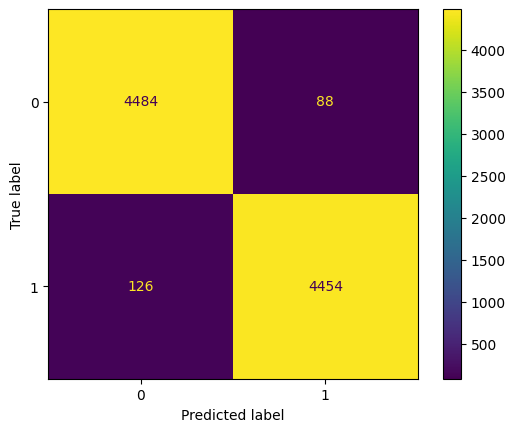

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

## 9. Real-world Testing

In [30]:
real_example = """In a case that could have an impact on the November presidential election, the Virginia Supreme Court heard arguments on Tuesday over a Republican lawsuit challenging the blanket restoration of voting rights for 206,000 felons by Democratic Governor Terry McAuliffe. If upheld, McAuliffe’s order could help tip Virginia, a swing state where the vote is traditionally close in presidential elections, in favor of presumptive Democratic presidential candidate Hillary Clinton. Lawyers for leaders in the Republican-controlled state legislature argued that McAuliffe exceeded his authority by restoring voting rights en masse, rather than on a case-by-case basis. “Never in Virginia’s 240-year history has a governor exercised clemency power en masse,” Charles Cooper, an attorney for the plaintiffs, told the court. Cooper said history and the language of the state constitution clearly indicate that the restoration of a felon’s rights must be done individually. But Stuart Raphael, Virginia’s solicitor general, said nothing in the constitution restricts McAuliffe’s authority to restore such rights across the board, even though no governor has done so in the past. “If he has the power,” Raphael said, “he has the power.” The plaintiffs have asked the court to block McAuliffe’s action, which also allows felons to serve on juries and hold public office. The court did not say on Tuesday when it may issue a decision in the case. Almost 12,000 felons have registered to vote since McAuliffe’s April 22 executive action, the state elections board said. Many of the convicts benefiting from the order are African-Americans or Latinos, two groups that have voted overwhelmingly for Democratic candidates in the past. Democrat Barack Obama won Virginia in 2012 by about 150,000 votes and in 2008 by about 235,000 votes.  Before the order, felons had to petition the governor individually to restore their voting rights. Virginia is one of four states whose constitutions permanently disenfranchise felons but allow the governor to restore voting rights, according to the Brennan Center for Justice, a non-partisan civil liberties group. McAuliffe and other Democrats have said the restoration of rights to felons who have served their sentences and completed probation is long overdue. The McAuliffe administration has refused to release the names of felons whose rights have been restored, a decision that drew criticism on Tuesday from Justice William Mims. “I cannot understand why a document of such importance has been shielded from litigants and the citizens of Virginia,” he said. 
 
"""

# fake news

fake_example = """A new movie about the Clinton Grifters couldn t be coming-out at a better time the day 
before the Democratic convention! The book that raked through the complex web of political, campaign 
fundraising, and political practices of Bill and Hillary Clinton last year and muddied Clinton s presidential 
campaign launch is coming to the big screen just in time to cause Clinton trouble in the general election.
 Clinton Cash  is set to premiere the day before the Democratic convention in Philadelphia, and is based on 
 the book by the same title by author Peter Schweizer.
 Schweizer is joined by fellow producer Stephan K.
   Bannon of conservative outlet Breitbart news on the project.A trailer for the film, which is directed by 
   M.A. Taylor., features images of blood dripping down piles of cash, Bloomberg News reported.The trailer 
   kicks off with clip of Clinton complimenting foreign governments for  rooting out corruption    even as 
Schweizer, who is interviewed as part of the film, says the Clintons  created a model for massive self 
enrichment that allows you to go into so-called pub service but get extremely rich at the same time.

The book s release in May prompted a series of investigations by major news outlets into the fundraising
practices of the Clinton foundation, which had accepted major contributions from corporations and 
foreign governments.It also probed hefty speaking fees earned by the Clintons from foreign and domestic
corporations after Bill Clinton left the White House, the foundation s charity work, and Clinton s 
time at the State Department.Read more: Daily Mail"""

samples = [real_example, fake_example]
predictions = model_pipeline.predict(samples)

for text, pred in zip(samples, predictions):
    label = "REAL" if pred == 1 else "FAKE"
    print(f"Predicted: {label}")
    print(f"Text: {text[:100]}...")
    print("---")

Predicted: REAL
Text: In a case that could have an impact on the November presidential election, the Virginia Supreme Cour...
---
Predicted: FAKE
Text: A new movie about the Clinton Grifters couldn t be coming-out at a better time the day 
before the D...
---


In [31]:
scores = model_pipeline.decision_function(samples)

for text, pred, score in zip(samples, predictions, scores):
    label = "REAL" if pred == 1 else "FAKE"
    print(f"Predicted: {label} | Confidence score: {score:.2f}")
    print(f"Text: {text[:100]}...")
    print("---")

Predicted: REAL | Confidence score: 0.40
Text: In a case that could have an impact on the November presidential election, the Virginia Supreme Cour...
---
Predicted: FAKE | Confidence score: -1.33
Text: A new movie about the Clinton Grifters couldn t be coming-out at a better time the day 
before the D...
---


### Interpretaion:
Validated against the ISOT Fake News Dataset (2015-2017, same era as training data) — 
model performed accurately, confirming reliability within its training time period. 
Performance degrades on more recent (2026) topics due to vocabulary/concept drift 
(see Limitations).

## 10. Conclusion/Limitation Section
Testing with current (2026) news articles revealed degraded performance , predictions 
became unstable/low-confidence (scores near 0) on topics/vocabulary not present in the 
training data (sourced from 2016-2017 news). This reflects a common real-world ML 
challenge: models trained on time-bound data experience "concept drift" and require 
periodic retraining on recent data to stay accurate. Future work: retrain periodically 
with recent news sources.

**Future work:** 
- Hyperparameter tuning via GridSearchCV (C, max_features) was not performed due to time constraints; current parameters are reasonable defaults, not optimized
- Periodic retraining with recent news sources to address concept drift
- Testing transformer-based models for better generalization to unfamiliar vocabulary/topics

## 11. Save The Model

In [32]:
import joblib
joblib.dump(model_pipeline , "Real&Fake_news.pkl")

['Real&Fake_news.pkl']